# 05. A full trajectory with `Process`

**Goal.** Drive Sapphire's `Process` over a bimetallic MD trajectory, read every result back with `IO.Reader`, and make the standard figures.

**You need.** Tutorials 01–04. Runs on the bundled down-sampled AuPt melting trajectory (no download).


## 5.1 The data

`Sapphire.Tutorials.data` gives three tiers: `sample()` (bundled, offline), `fetch()` (the full 14 ns
runs from the GitHub release) and `synthetic()` (a seeded ASE/EMT toy). The sample is Sim‑1345 of the
Au₈₀Pt₂₀ random alloy heated 300 → 1000 K at 50 K ns⁻¹, one frame every 200 ps.

In [1]:
import os, numpy as np, matplotlib.pyplot as plt
from Sapphire import Process
from Sapphire.Tutorials import data

work = os.path.abspath("run_AuPt") + "/"
os.makedirs(work, exist_ok=True)
movie = data.sample("AuPt", work)                 # bundled: every 20th frame (200 ps) of a 1415-atom Au80Pt20 melt
print(movie)

/Users/robjones/Documents/Personal/Projects/Physics/Sapphire/main/Sapphire/Tutorials/05_Trajectory_Analysis_with_Process/run_AuPt/AuPt_sample.xyz


## 5.2 Describing the analysis

Two dictionaries drive everything. `System` says where the data are and which frames to analyse;
`Quantities` lists what to compute, grouped as `Full` (whole cluster), `Homo` (per species) and
`Hetero` (between species). The supported keys are listed in `Sapphire.Utilities.Supported`.

Results are **written to files** under `base_dir` as they are computed (see `docs/FILE_CONTRACT.md`),
so a long run can be inspected while it is still going and never has to be repeated to re-plot.

In [2]:
System = {"base_dir": work, "movie_file_name": "AuPt_sample.xyz", "extend_xyz": None,
          "Homo": ["Au", "Pt"], "Hetero": True,
          "Start": 0, "End": 70, "Step": 23,            # 4 frames: 0, 23, 46, 69  (0, 4.6, 9.2, 13.8 ns)
          "Skip": 1, "UniformPDF": False, "Band": 0.05}
Quantities = {
    "Full":   {"pdf": None, "rdf": None, "adj": None, "nn": None, "agcn": None, "cna_sigs": None, "cna_patterns": None,
               "com": None, "comdist": None, "gyration": None, "surf_atoms": None},
    "Homo":   {"hopdf": None, "hoadj": None, "hocomdist": None, "homobonds": None},
    "Hetero": {"hepdf": None, "headj": None, "mix": None, "lae": None, "ele_nn": None, "heterobonds": None},
}
proc = Process.Process(System=System, Quantities=Quantities)      # ~20 s
print(open(work + "Sapphire_Errors.log").read()[-300:] if os.path.exists(work + "Sapphire_Errors.log") else "no errors logged")

no errors logged


## 5.3 Reading it back

`Process.reader()` (a `Sapphire.IO.Reader.Reader`) maps the files to arrays indexed `[frame, ...]`.

In [3]:
r = proc.reader()
meta = r.load_all()
for k in sorted(meta):
    v = meta[k]; print(f"{k:16s} {getattr(v, 'shape', type(v).__name__)}")

adj              (4, 1415, 1415)
agcn             (4, 1415)
cna_sigs         list
com              (4, 3)
comdist          (4, 1415)
ele_nnAu         (4, 1415)
ele_nnPt         (4, 1415)
gyration         (4,)
headj            (4, 1149, 266)
hecut            (4,)
hepdf            (4, 200)
hepdfspace       (4, 200)
hetero_bonds     (4,)
hoadjAu          (4, 1149, 1149)
hoadjPt          (4, 266, 266)
hocutAu          (4,)
hocutPt          (4,)
homo_bondsAu     (4,)
homo_bondsPt     (4,)
hopdfAu          (4, 200)
hopdfPt          (4, 200)
hopdfspaceAu     (4, 200)
hopdfspacePt     (4, 200)
laeAu            (4, 13)
laePt            (4, 13)
masterkey        list
mix              (4,)
nn               (4, 1415)
pattern_indices  list
pdf              (4, 200)
pdfspace         (4, 200)
rcut             (4,)
rdf              (4, 100)
rdfspace         (4, 100)
surf_atoms       (4, 1415)


Species-resolved quantities carry the symbol (`hocomdistAu`); per-frame matrices come back as 3-D arrays
(`adj`, `headj`, `hoadjPt`). Let us look at a few things physically.

## 5.4 Melting, seen four ways

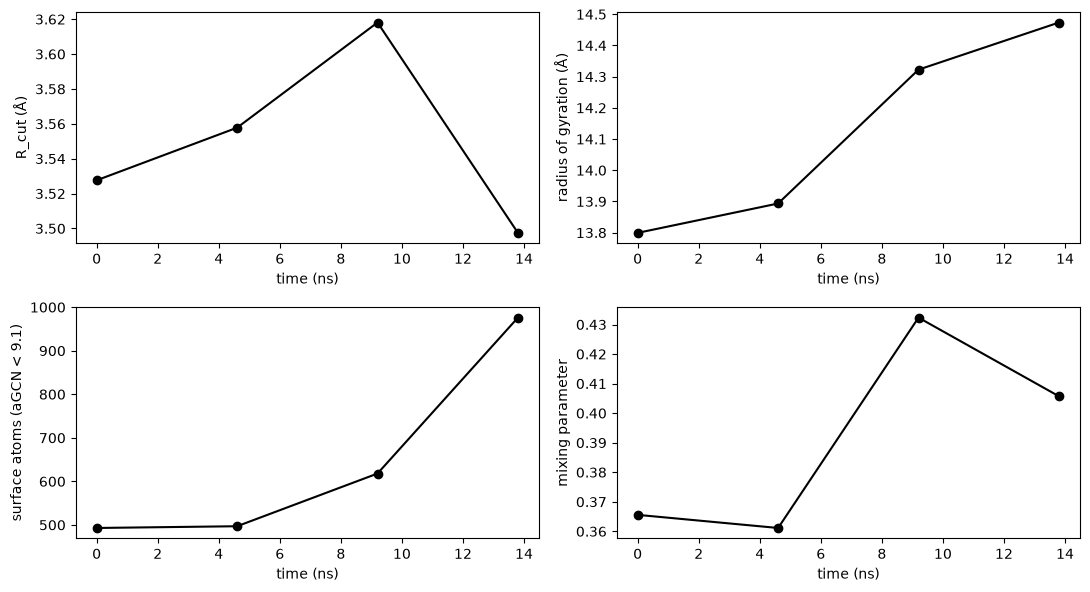

In [4]:
frames = r.frames("nn"); t_ns = frames * 0.2
fig, ax = plt.subplots(2, 2, figsize=(11, 6))
ax[0,0].plot(t_ns, meta["rcut"], "ko-"); ax[0,0].set_ylabel("R_cut (Å)")
ax[0,1].plot(t_ns, meta["gyration"], "ko-"); ax[0,1].set_ylabel("radius of gyration (Å)")
ax[1,0].plot(t_ns, meta["surf_atoms"].sum(1), "ko-"); ax[1,0].set_ylabel("surface atoms (aGCN < 9.1)")
ax[1,1].plot(t_ns, meta["mix"], "ko-"); ax[1,1].set_ylabel("mixing parameter")
for a in ax.flat: a.set_xlabel("time (ns)")
plt.tight_layout(); plt.show()

* **R_cut** grows with thermal expansion, then jumps as the first shell smears out.
* **Radius of gyration** rises on melting (the liquid is less dense).
* **Surface atoms** increase as the facets roughen.
* **Mixing parameter** (N_AA + N_BB − N_AB)/(N_AA + N_BB + N_AB): +1 is fully segregated, −1 fully
  alternating. Watch whether the liquid alloy mixes or demixes.

## 5.5 Chemical ordering in detail

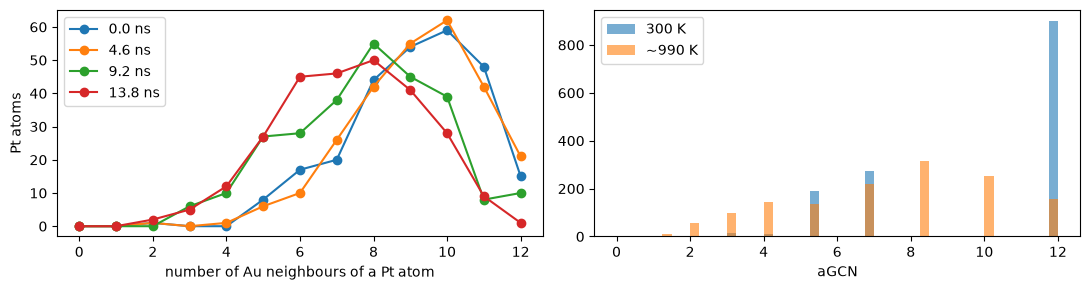

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3))
for f in range(len(frames)):
    ax[0].plot(range(13), meta["laePt"][f], "o-", label=f"{t_ns[f]:.1f} ns")
ax[0].set_xlabel("number of Au neighbours of a Pt atom"); ax[0].set_ylabel("Pt atoms"); ax[0].legend()
ax[1].hist(meta["agcn"][0], bins=48, range=(0, 12), alpha=.6, label="300 K"); ax[1].hist(meta["agcn"][-1], bins=48, range=(0, 12), alpha=.6, label="~990 K")
ax[1].set_xlabel("aGCN"); ax[1].legend(); plt.tight_layout(); plt.show()

## 5.6 Standard figures with `Graphing`

`Graphing.Read_Meta` adapts the run directory for `Plot_Funcs`, whose methods are selected by name in a
dictionary. `frame_dt` and `temperature` are optional annotations.

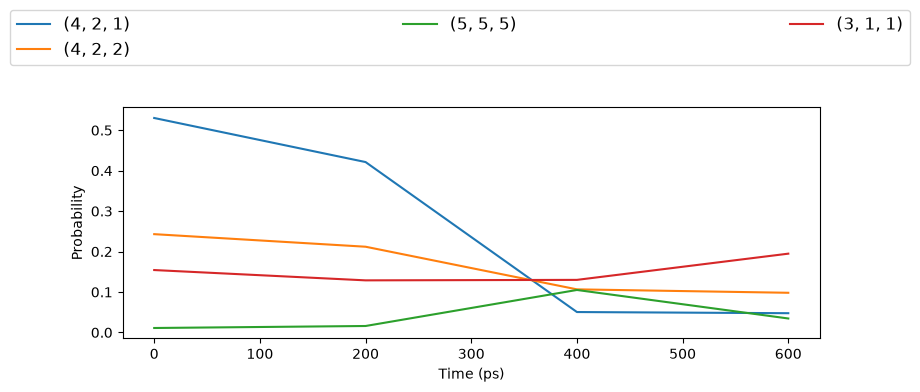

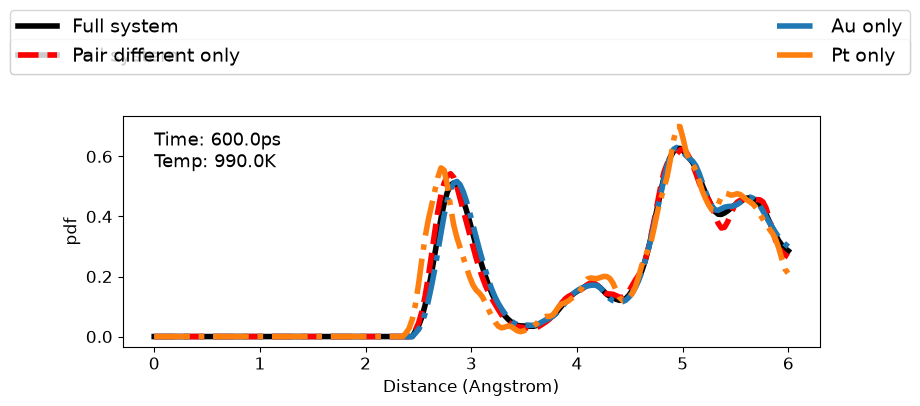

In [6]:
from Sapphire.Graphing import Reader as GReader, Plot_Funcs
PS = {"base_dir": work, "plot_dir": "Images/", "frame_dt": 200.0, "temperature": 300 + 50 * t_ns}
avg, err = GReader.Read_Meta(PS).Average()
Plot_Funcs.Plot_Funcs(avg, Quantities={"cna_traj": {"Sigs": [(4,2,1), (4,2,2), (5,5,5), (3,1,1)]},
                                        "prdf_plot": {"Names": ["pdf"], "Frames": [0, 3], "He": True, "Ho": ["Au", "Pt"]}},
                      System=PS, Errors=err).Make_Plots()
from IPython.display import Image, display
for f in ["CNA_Traj.png", "PDF_He__Ho_AuPt_3.png"]:
    display(Image(work + "Images/" + f))

## 5.7 Try it

* `data.fetch("AuPt")` downloads the full 700-frame run (58 MB); set `"Step": 10` for a 70-frame analysis.
* Add `"extend_xyz": ["nn", "agcn"]` to `System` and open `Extended.xyz` in OVITO — colour atoms by aGCN.
* Repeat for `"CuNi"` (Janus, melting) and compare the mixing parameter's trend.

**Next:** *06 — Statistics along a trajectory: divergences, collectivity and change-points.*